Using device: cuda
Train dataset size: 2137
Validation dataset size: 154
Epoch 1/50
  Train - Loss: 0.1817, Dice: 0.7564
  Val   - Loss: 0.1504, Dice: 0.7290
  New best model saved! Dice: 0.7290
--------------------------------------------------
Epoch 2/50
  Train - Loss: 0.1063, Dice: 0.8366
  Val   - Loss: 0.1015, Dice: 0.8375
  New best model saved! Dice: 0.8375
--------------------------------------------------
Epoch 3/50
  Train - Loss: 0.0870, Dice: 0.8663
  Val   - Loss: 0.0879, Dice: 0.8667
  New best model saved! Dice: 0.8667
--------------------------------------------------
Epoch 4/50
  Train - Loss: 0.0749, Dice: 0.8851
  Val   - Loss: 0.0836, Dice: 0.8808
  New best model saved! Dice: 0.8808
--------------------------------------------------
Epoch 5/50
  Train - Loss: 0.0671, Dice: 0.8973
  Val   - Loss: 0.0895, Dice: 0.8710
--------------------------------------------------
Epoch 6/50
  Train - Loss: 0.0608, Dice: 0.9076
  Val   - Loss: 0.0704, Dice: 0.8952
  New best mod

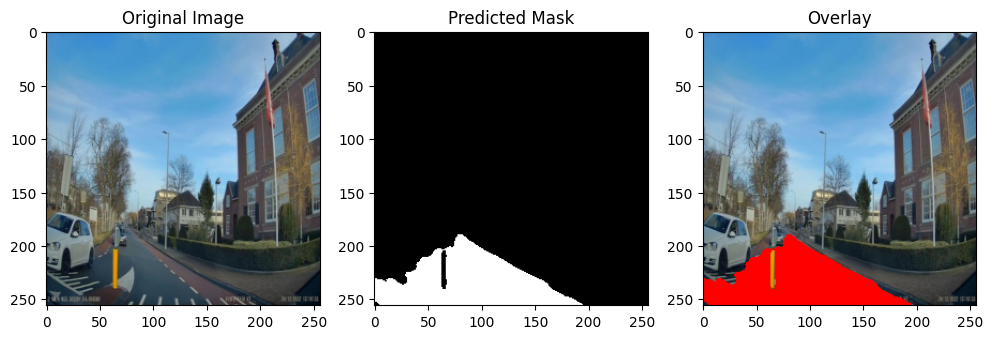

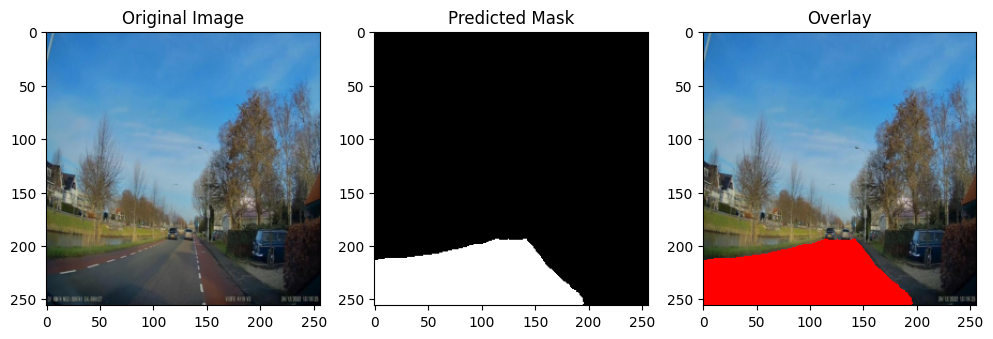

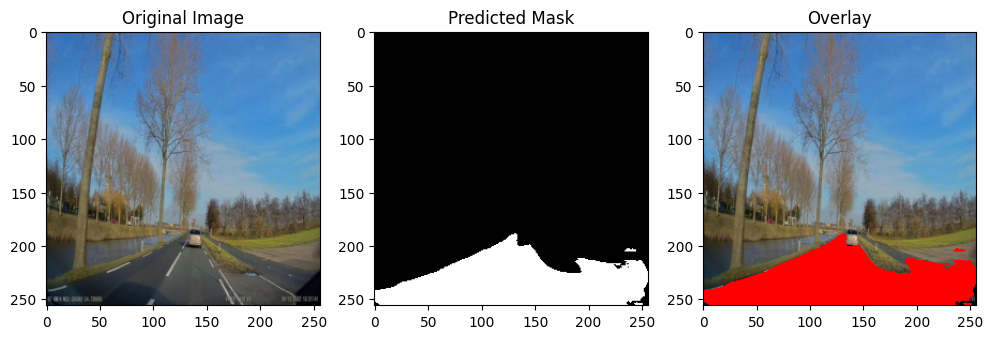

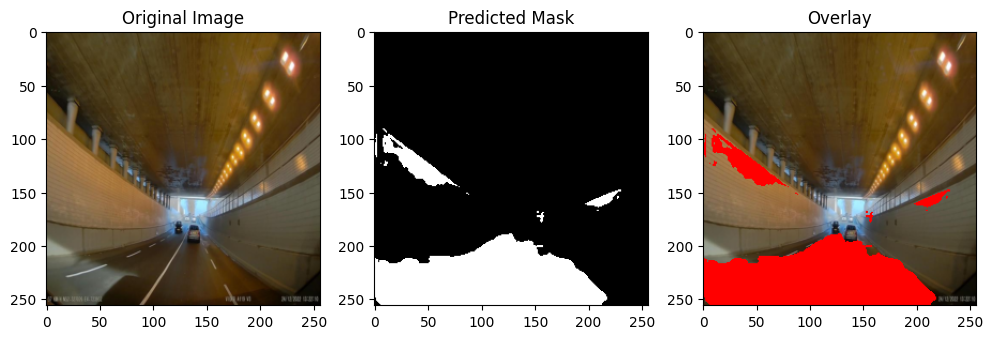

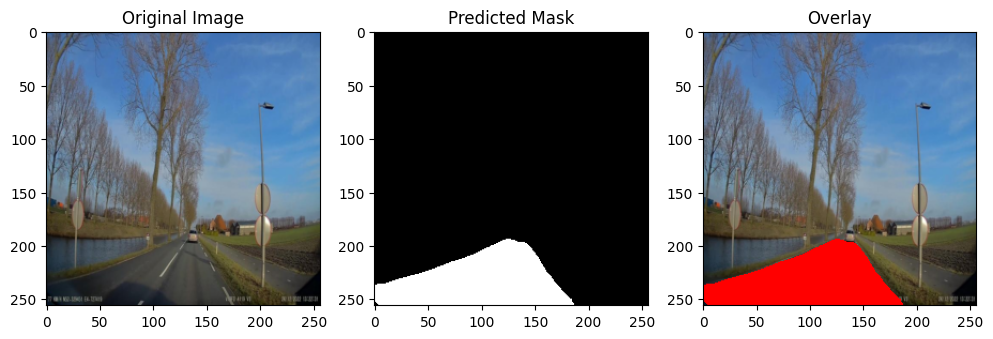

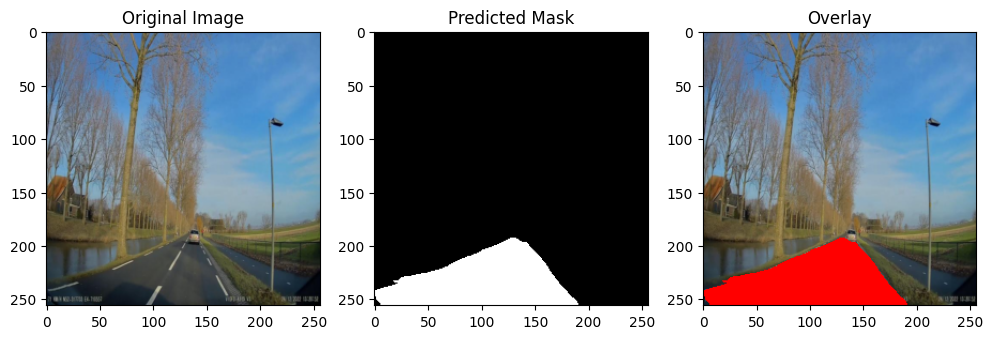

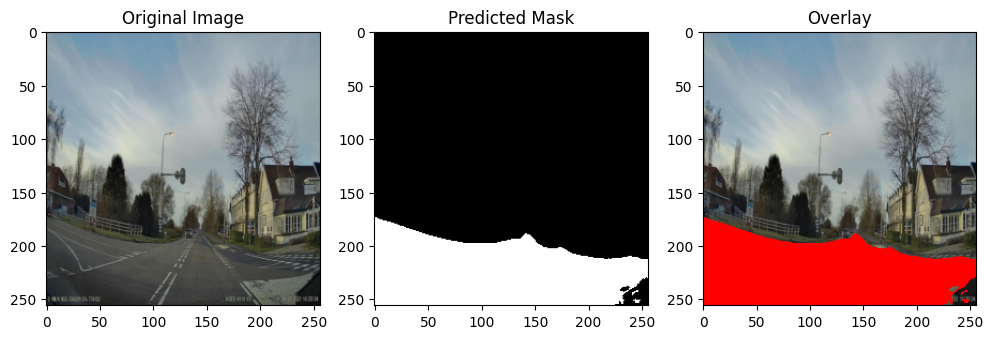

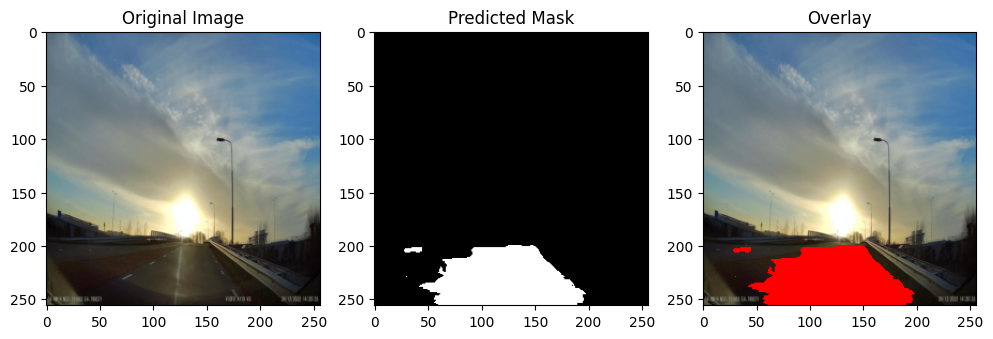

In [12]:
import os
import time
import glob
import numpy as np
from PIL import Image, ImageDraw

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# --- Dataset ---
class RoadSegDataset(Dataset):
    def __init__(self, images_dir, labels_dir, transform=None):
        self.images_paths = sorted(glob.glob(os.path.join(images_dir, "*.jpg")))
        self.labels_paths = sorted(glob.glob(os.path.join(labels_dir, "*.txt")))
        self.transform = transform

    def __len__(self):
        return len(self.images_paths)

    def parse_polygon_mask(self, label_path, image_size):
        """
        Parse YOLO polygon format and create binary mask
        """
        mask = Image.new("L", image_size, 0)  # Start with black mask
        
        if not os.path.exists(label_path):
            return mask
            
        with open(label_path, 'r') as f:
            lines = f.readlines()
        
        draw = ImageDraw.Draw(mask)
        
        for line in lines:
            parts = line.strip().split()
            if len(parts) < 3:  # Need at least class_id + 1 point (x,y)
                continue
                
            class_id = int(parts[0])
            coords = list(map(float, parts[1:]))
            
            # Convert normalized coordinates to pixel coordinates
            if len(coords) >= 6 and len(coords) % 2 == 0:  # At least 3 points and even number
                pixel_coords = []
                for i in range(0, len(coords), 2):
                    x = coords[i] * image_size[0]
                    y = coords[i + 1] * image_size[1]
                    pixel_coords.extend([x, y])
                
                # Draw filled polygon (white = 255 for road class)
                draw.polygon(pixel_coords, fill=255)
        
        return mask

    def __getitem__(self, idx):
        img_path = self.images_paths[idx]
        label_path = self.labels_paths[idx]

        image = Image.open(img_path).convert("RGB")
        
        # Create real mask from polygon coordinates
        mask = self.parse_polygon_mask(label_path, image.size)

        if self.transform:
            # Apply same transform to both image and mask
            if isinstance(self.transform, transforms.Compose):
                # For proper mask handling, we need to treat mask differently
                image = self.transform(image)
                
                # Transform mask separately (avoid normalization)
                mask_transform = transforms.Compose([
                    transforms.Resize((256, 256)),
                    transforms.ToTensor(),
                ])
                mask = mask_transform(mask)
                
                # Ensure mask is binary (0 or 1)
                mask = (mask > 0.5).float()
            else:
                image = self.transform(image)
                mask = self.transform(mask)

        return image, mask

# --- UNet Model ---

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, n_channels=3, n_classes=1):
        super().__init__()

        self.dconv_down1 = DoubleConv(n_channels, 64)
        self.dconv_down2 = DoubleConv(64, 128)
        self.dconv_down3 = DoubleConv(128, 256)
        self.dconv_down4 = DoubleConv(256, 512)

        self.maxpool = nn.MaxPool2d(2)
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

        self.dconv_up3 = DoubleConv(256 + 512, 256)
        self.dconv_up2 = DoubleConv(128 + 256, 128)
        self.dconv_up1 = DoubleConv(128 + 64, 64)

        self.conv_last = nn.Conv2d(64, n_classes, 1)

    def forward(self, x):
        # Encoder
        conv1 = self.dconv_down1(x)
        x = self.maxpool(conv1)

        conv2 = self.dconv_down2(x)
        x = self.maxpool(conv2)

        conv3 = self.dconv_down3(x)
        x = self.maxpool(conv3)

        x = self.dconv_down4(x)

        # Decoder
        x = self.upsample(x)
        x = torch.cat([x, conv3], dim=1)

        x = self.dconv_up3(x)
        x = self.upsample(x)
        x = torch.cat([x, conv2], dim=1)

        x = self.dconv_up2(x)
        x = self.upsample(x)
        x = torch.cat([x, conv1], dim=1)

        x = self.dconv_up1(x)

        out = self.conv_last(x)

        return torch.sigmoid(out)

# --- Train ve Test Fonksiyonları ---

def dice_coefficient(pred, target, smooth=1e-6):
    """Calculate Dice coefficient for evaluation"""
    pred = pred.view(-1)
    target = target.view(-1)
    
    intersection = (pred * target).sum()
    dice = (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)
    
    return dice

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    running_dice = 0.0
    
    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        # Calculate metrics
        running_loss += loss.item() * images.size(0)
        
        # Calculate Dice coefficient
        with torch.no_grad():
            pred_binary = (outputs > 0.5).float()
            dice = dice_coefficient(pred_binary, masks)
            running_dice += dice.item() * images.size(0)
    
    avg_loss = running_loss / len(loader.dataset)
    avg_dice = running_dice / len(loader.dataset)
    
    return avg_loss, avg_dice

def validate_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_dice = 0.0
    
    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, masks)
            
            running_loss += loss.item() * images.size(0)
            
            # Calculate Dice coefficient
            pred_binary = (outputs > 0.5).float()
            dice = dice_coefficient(pred_binary, masks)
            running_dice += dice.item() * images.size(0)
    
    avg_loss = running_loss / len(loader.dataset)
    avg_dice = running_dice / len(loader.dataset)
    
    return avg_loss, avg_dice

def test_fps(model, loader, device):
    model.eval()
    total_time = 0.0
    total_images = 0
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            start = time.time()
            outputs = model(images)
            torch.cuda.synchronize() if device.type == 'cuda' else None
            end = time.time()

            batch_time = end - start
            total_time += batch_time
            total_images += images.size(0)

    fps = total_images / total_time
    return fps

# --- Main ---

if __name__ == "__main__":
    # Yol değiştir
    train_images_dir = "/kaggle/input/road-detection-segmentation/train/images"
    train_labels_dir = "/kaggle/input/road-detection-segmentation/train/labels"

    val_images_dir = "/kaggle/input/road-detection-segmentation/valid/images"
    val_labels_dir = "/kaggle/input/road-detection-segmentation/valid/labels"

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Updated transform - normalize images but not masks
    image_transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    train_dataset = RoadSegDataset(train_images_dir, train_labels_dir, transform=image_transform)
    val_dataset = RoadSegDataset(val_images_dir, val_labels_dir, transform=image_transform)

    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2)

    print(f"Train dataset size: {len(train_dataset)}")
    print(f"Validation dataset size: {len(val_dataset)}")

    model = UNet(n_channels=3, n_classes=1).to(device)
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    epochs = 50
    best_dice = 0.0
    
    for epoch in range(epochs):
        train_loss, train_dice = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_dice = validate_epoch(model, val_loader, criterion, device)
        
        print(f"Epoch {epoch+1}/{epochs}")
        print(f"  Train - Loss: {train_loss:.4f}, Dice: {train_dice:.4f}")
        print(f"  Val   - Loss: {val_loss:.4f}, Dice: {val_dice:.4f}")
        
        # Save best model
        if val_dice > best_dice:
            best_dice = val_dice
            torch.save(model.state_dict(), 'best_road_segmentation_model.pth')
            print(f"  New best model saved! Dice: {best_dice:.4f}")
        
        print("-" * 50)

    fps = test_fps(model, val_loader, device)
    print(f"Validation FPS: {fps:.2f}")
    print(f"Best Dice Score: {best_dice:.4f}")

    # Test with a few examples
    # Test with a few examples
model.eval()
with torch.no_grad():
    for i, (images, masks) in enumerate(val_loader):
        if i >= 1:  # sadece ilk batch için gösterim yapalım
            break

        images = images.to(device)
        outputs = model(images)
        pred_masks = (outputs > 0.5).float().cpu()

        print(f"Batch {i+1}: True mask sum: {masks.sum().item():.1f}, "
              f"Pred mask sum: {pred_masks.sum().item():.1f}")

        # --- Görselleştirme kısmı ---
        import matplotlib.pyplot as plt
        import numpy as np

        for j in range(images.size(0)):  # batch içindeki her görüntü
            img = images[j].cpu().permute(1, 2, 0).numpy()
            img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])  # unnormalize
            img = np.clip(img, 0, 1)

            mask = pred_masks[j][0].numpy()
            overlay = img.copy()
            overlay[mask > 0.5] = [1, 0, 0]  # kırmızı yerler tahmin maskesi

            plt.figure(figsize=(12, 4))
            plt.subplot(1, 3, 1)
            plt.imshow(img)
            plt.title("Original Image")

            plt.subplot(1, 3, 2)
            plt.imshow(mask, cmap='gray')
            plt.title("Predicted Mask")

            plt.subplot(1, 3, 3)
            plt.imshow(overlay)
            plt.title("Overlay")

            plt.show()
